In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load preprocessed data



In [ ]:
df_preprocessed = pd.read_csv("/content/preprocessed_lung_cancer_data.csv")

print(f"Shape of the preprocessed DataFrame: {df_preprocessed.shape}")

Shape of the preprocessed DataFrame: (100211, 41)


## Split data




In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
# Exclude 'id', 'diagnosis_date', and 'end_treatment_date' as they are not typically used as features for training
features = df_preprocessed.drop(['id', 'diagnosis_date', 'end_treatment_date', 'survived'], axis=1)
target = df_preprocessed['survived']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=42)

# Print the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (75158, 37)
Shape of X_test: (25053, 37)
Shape of y_train: (75158,)
Shape of y_test: (25053,)


##Hyperparameter Tuning

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for hyperparameter tuning
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
              'solver': ['liblinear', 'lbfgs']}

# Create a logistic regression model
logistic_regression = LogisticRegression(max_iter=1000) # Increased max_iter

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(logistic_regression, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_

print("Best hyperparameters found:", best_params)

Best hyperparameters found: {'C': 0.001, 'solver': 'liblinear'}


##Training the model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train the logistic regression model with the best hyperparameters
best_logistic_regression_model = LogisticRegression(**best_params, max_iter=1000)
best_logistic_regression_model.fit(X_train, y_train)

LogisticRegression(C=0.001, max_iter=1000, solver='liblinear')

##1st Evaluation

In [ ]:
# Make predictions on the test set
y_pred = best_logistic_regression_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Model Evaluation Results:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-score: {f1:.4f}")

Model Evaluation Results:
  Accuracy: 0.7801
  Precision: 0.0000
  Recall: 0.0000
  F1-score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Handle class imbalance




In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))

print("Calculated Class Weights:")
print(class_weight_dict)

Calculated Class Weights:
{np.int64(0): np.float64(0.6414002628479749), np.int64(1): np.float64(2.2680306596656408)}


## Hyperparameter tuning




In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, f1_score, make_scorer

# Define the parameter grid
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2']}

# Create a Logistic Regression model instance with class weights
lr = LogisticRegression(solver='liblinear', class_weight=class_weight_dict, random_state=42)

# Define scoring metrics for GridSearchCV
scoring = {'recall': make_scorer(recall_score), 'f1': make_scorer(f1_score)}

# Instantiate GridSearchCV
grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring=scoring, refit='recall')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and best score
print("Best hyperparameters found by GridSearchCV:")
print(grid_search.best_params_)
print("\nBest score found by GridSearchCV (based on refit metric):")
print(grid_search.best_score_)

Best hyperparameters found by GridSearchCV:
{'C': 0.01, 'penalty': 'l2'}

Best score found by GridSearchCV (based on refit metric):
0.4917023171460574


## Training the model




In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, make_scorer, accuracy_score, precision_score
from sklearn.model_selection import GridSearchCV

# Retrieve the best estimator from grid_search
best_logistic_model = grid_search.best_estimator_

# Fit the best estimator to the training data
best_logistic_model.fit(X_train, y_train)

LogisticRegression(C=0.01,
                   class_weight={np.int64(0): np.float64(0.6414002628479749),
                                 np.int64(1): np.float64(2.2680306596656408)},
                   random_state=42, solver='liblinear')

## Training Logistic Regression without Hyperparameter Tuning

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

default_logistic_regression_model = LogisticRegression(class_weight=class_weight_dict, random_state=42, max_iter=1000)
default_logistic_regression_model.fit(X_train, y_train)



LogisticRegression(class_weight={np.int64(0): np.float64(0.6414002628479749),
                                 np.int64(1): np.float64(2.2680306596656408)},
                   max_iter=1000, random_state=42)

## Evaluation without hyperparameter tuning




--- Results without Hyperparameter Tuning ---
  Accuracy: 0.5167
  Precision: 0.2244
  Recall: 0.4876
  F1-score: 0.3073


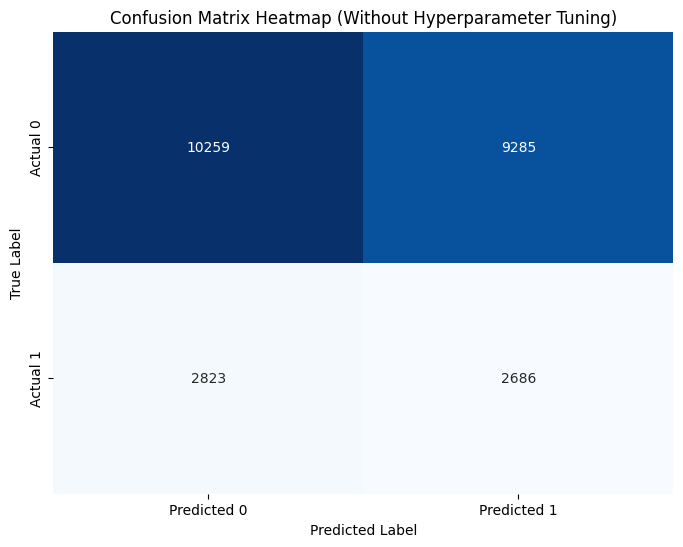

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_default = default_logistic_regression_model.predict(X_test)

# Evaluate the model
accuracy_default = accuracy_score(y_test, y_pred_default)
precision_default = precision_score(y_test, y_pred_default)
recall_default = recall_score(y_test, y_pred_default)
f1_default = f1_score(y_test, y_pred_default)

print("--- Results without Hyperparameter Tuning ---")
print(f"  Accuracy: {accuracy_default:.4f}")
print(f"  Precision: {precision_default:.4f}")
print(f"  Recall: {recall_default:.4f}")
print(f"  F1-score: {f1_default:.4f}")

# Generate the confusion matrix
conf_matrix_default = confusion_matrix(y_test, y_pred_default)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_default, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap (Without Hyperparameter Tuning)')
plt.show()

## Evaluation with hyperparameter tuning




Accuracy: 0.5151
Precision: 0.2232
Recall: 0.4861
F1 Score: 0.3060


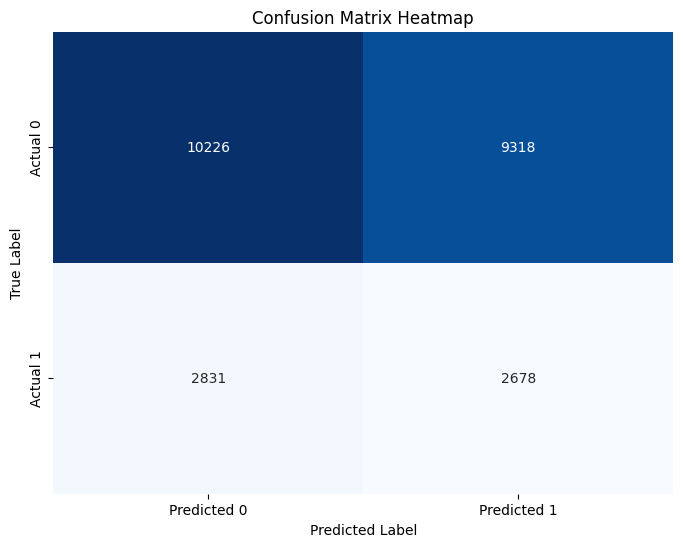

In [ ]:
# Make predictions on the test data
y_pred = best_logistic_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()